In [1]:
# Cell 1: Imports and data loading
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pickle

df = pd.read_csv("../outputs/loan_book_clean.csv")
train = df[df["set"] == "train"].copy()
test = df[df["set"] == "test"].copy()

print(f"Train: {len(train)} rows | Test: {len(test)} rows")

Train: 84264 rows | Test: 36080 rows


In [2]:
# Cell 2: Prepare features for baseline
baseline_features = [
    "age", "annual_income", "employment_length_years",
    "num_open_accounts", "num_delinquencies_2yr",
    "total_revolving_balance", "credit_utilisation_pct",
    "num_hard_inquiries_6mo",
    "loan_amount", "interest_rate", "dti_ratio",
    "months_since_last_delinquency", "pct_accounts_current",
    "months_at_current_address"
]

X_train = train[baseline_features]
y_train = train["default_flag"]

X_test = test[baseline_features]
y_test = test["default_flag"]

print(f"Features: {len(baseline_features)}")
print(f"X_train shape: {X_train.shape}")

Features: 14
X_train shape: (84264, 14)


In [3]:
# Cell 3: Scale and fit
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

# Predict probabilities on test set
y_pred_proba = baseline_model.predict_proba(X_test_scaled)[:,1]

baseline_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Baseline AUC: {baseline_auc}")

Baseline AUC: 0.7886551038431173


## Baseline Model

**Approach:** All 15 numeric features were used, as well as scaling but no feature engineering.

**Result:** Baseline AUC: 0.7886551038431173 (0.789)

**Note:** An older model had an AUC of 0.68, this baseline model is higher because the data was carefully cleaned (categorical normalisation, sensible missing value handling for months_since_last_delinquency, outlier capping) and I included all available numeric features into the model. The next step is to use feature engineering to hopefully beat 0.789

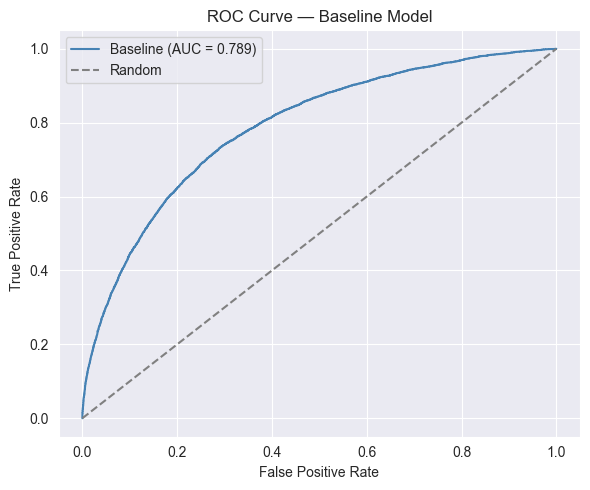

In [4]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", label=f"Baseline (AUC = {baseline_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Baseline Model")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Create all candidate features

train_eng = train.copy()
test_eng = test.copy()

# How much of their income is the loan?
train_eng["income_to_loan_ratio"] = train["annual_income"] / (train["loan_amount"] + 1)
test_eng["income_to_loan_ratio"] = test["annual_income"] / (test["loan_amount"] + 1)

# Income relative to interest rate (bivariate finding)
train_eng["income_rate_ratio"] = train["annual_income"] / (train["interest_rate"] + 1)
test_eng["income_rate_ratio"] = test["annual_income"] / (test["interest_rate"] + 1)

# Delinquency count relative to recency
train_eng["delinquency_severity"] = (
    train["num_delinquencies_2yr"] / (train["months_since_last_delinquency"] + 1)
)
test_eng["delinquency_severity"] = (
    test["num_delinquencies_2yr"] / (test["months_since_last_delinquency"] + 1)
)

# Revolving balance relative to income
train_eng["revolving_to_income"] = (
    train["total_revolving_balance"] / (train["annual_income"] + 1)
)
test_eng["revolving_to_income"] = (
    test["total_revolving_balance"] / (test["annual_income"] + 1)
)

#  Double debt burden [(loan to income) * dti]
train_eng["loan_income_x_dti"] = (
    (train["loan_amount"] / (train["annual_income"] + 1)) * train["dti_ratio"]
)
test_eng["loan_income_x_dti"] = (
    (test["loan_amount"] / (test["annual_income"] + 1)) * test["dti_ratio"]
)

new_features = [
    "income_to_loan_ratio",
    "income_rate_ratio",
    "delinquency_severity",
    "revolving_to_income",
    "loan_income_x_dti",
]

print("Candidate features created:")
for f in new_features:
    print(f"  - {f}")

Candidate features created:
  - income_to_loan_ratio
  - income_rate_ratio
  - delinquency_severity
  - revolving_to_income
  - loan_income_x_dti


In [6]:
# Test each feature individually
results = []

for feat in new_features:
    test_features = baseline_features + [feat]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(train_eng[test_features])
    X_te = scaler.transform(test_eng[test_features])

    model = LogisticRegression(max_iter=5000, solver="saga", random_state=42)
    model.fit(X_tr, y_train)

    y_pred = model.predict_proba(X_te)[:,1]
    auc = roc_auc_score(y_test, y_pred)
    change = auc - baseline_auc

    results.append({
        "feature": feat,
        "auc": round(auc, 4),
        "change": round(change, 4),
    })
    print(f"{feat:30s} AUC: {auc:.4f} ({change:+.4f})")

print(f"\n{'Baseline':30s} AUC: {baseline_auc:.4f}")
results_df = pd.DataFrame(results).sort_values("change", ascending=False)
print(f"\nRanked by improvement:")
print(results_df.to_string(index=False))

income_to_loan_ratio           AUC: 0.7889 (+0.0003)
income_rate_ratio              AUC: 0.7883 (-0.0003)
delinquency_severity           AUC: 0.7890 (+0.0004)
revolving_to_income            AUC: 0.7888 (+0.0001)
loan_income_x_dti              AUC: 0.7913 (+0.0026)

Baseline                       AUC: 0.7887

Ranked by improvement:
             feature    auc  change
   loan_income_x_dti 0.7913  0.0026
delinquency_severity 0.7890  0.0004
income_to_loan_ratio 0.7889  0.0003
 revolving_to_income 0.7888  0.0001
   income_rate_ratio 0.7883 -0.0003


In [7]:
helpful_features = [r["feature"] for r in results if r["change"] > 0]
print(f"Helpful features: {helpful_features}")

if len(helpful_features) == 0:
    print("None of the engineered features helped improve AUC")
    print("Using baseling features only")
    final_features = baseline_features
else:
    final_features = baseline_features + helpful_features
    print(f"\nFinal feature set: {len(final_features)} features")

final_scaler = StandardScaler()
X_train_final = final_scaler.fit_transform(train_eng[final_features])
X_test_final = final_scaler.transform(test_eng[final_features])

final_model = LogisticRegression(max_iter=5000, solver="saga", random_state=42)
final_model.fit(X_train_final, y_train)

y_pred_final = final_model.predict_proba(X_test_final)[:,1]
final_auc = roc_auc_score(y_test, y_pred_final)

print(f"\nBaseline AUC: {baseline_auc:.4f}")
print(f"Final AUC: {final_auc:.4f}")
print(f"Change: {final_auc - baseline_auc:.4f}")

Helpful features: ['income_to_loan_ratio', 'delinquency_severity', 'revolving_to_income', 'loan_income_x_dti']

Final feature set: 18 features

Baseline AUC: 0.7887
Final AUC: 0.7918
Change: 0.0031


In [8]:
# SUMMARY OF FEATURE ENGINEERING RESULTS
print("Features tested and their impact on AUC:\n")
print(results_df.to_string(index=False))
print(f"\nDropped: income_to_rate_ratio (hurt AUC)")
print(f"Kept: {helpful_features}")
print(f"\nBaseline AUC: {baseline_auc:.4f}")
print(f"Final AUC: {final_auc:.4f}")
print(f"Improvement: {final_auc - baseline_auc:.4f}")

Features tested and their impact on AUC:

             feature    auc  change
   loan_income_x_dti 0.7913  0.0026
delinquency_severity 0.7890  0.0004
income_to_loan_ratio 0.7889  0.0003
 revolving_to_income 0.7888  0.0001
   income_rate_ratio 0.7883 -0.0003

Dropped: income_to_rate_ratio (hurt AUC)
Kept: ['income_to_loan_ratio', 'delinquency_severity', 'revolving_to_income', 'loan_income_x_dti']

Baseline AUC: 0.7887
Final AUC: 0.7918
Improvement: 0.0031


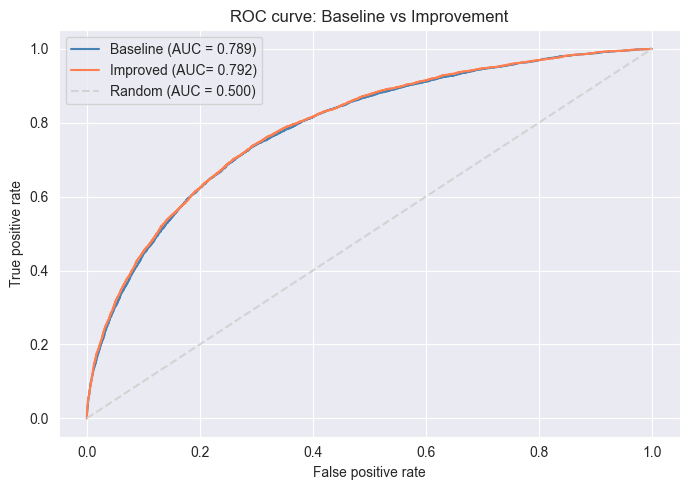

In [9]:
# Plotting both ROC curves together for comparison

fpr_base, tpr_base, _ = roc_curve(y_test, y_pred_proba)     # Baseline ROC
fpr_imp, tpr_imp, _ = roc_curve(y_test, y_pred_final)       # Improved ROC

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_base, tpr_base, color="steelblue", label=f"Baseline (AUC = {baseline_auc:.3f})")
ax.plot(fpr_imp, tpr_imp, color="coral", label=f"Improved (AUC= {final_auc:.3f})")
ax.plot([0,1], [0,1], color="lightgrey", linestyle="--", label=f"Random (AUC = 0.500)")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve: Baseline vs Improvement")
ax.legend()

plt.tight_layout()
plt.show()

In [10]:
# Model Equation
print("Final Model Equation\n")
print("P(default) = 1 / (1 + e^(-n))\n")
print("where n =")

intercept = final_model.intercept_[0]
coefficients = final_model.coef_[0]

print(f"    {intercept:+.4f} (intercept)")
for name, coef in zip(final_features, coefficients):
    print(f"    {coef:+.4f} * {name}")

Final Model Equation

P(default) = 1 / (1 + e^(-n))

where n =
    -2.1613 (intercept)
    -0.4538 * age
    -0.1665 * annual_income
    -0.2119 * employment_length_years
    +0.1524 * num_open_accounts
    +0.1334 * num_delinquencies_2yr
    -0.0783 * total_revolving_balance
    +0.2554 * credit_utilisation_pct
    +0.2781 * num_hard_inquiries_6mo
    -0.2834 * loan_amount
    +0.0885 * interest_rate
    -0.0183 * dti_ratio
    -0.4934 * months_since_last_delinquency
    -0.0722 * pct_accounts_current
    -0.0032 * months_at_current_address
    -0.1835 * income_to_loan_ratio
    +0.1309 * delinquency_severity
    +0.0572 * revolving_to_income
    +0.2716 * loan_income_x_dti


In [11]:
# Baseline scaler is overwritten so we are recreating it
baseline_scaler = StandardScaler()
baseline_scaler.fit(train[baseline_features])

X_test_check = baseline_scaler.transform(test[baseline_features])
y_check = baseline_model.predict_proba(X_test_check)[:, 1]
print(f"Baseline AUC check: {roc_auc_score(y_test, y_check):.4f}")

Baseline AUC check: 0.7887


In [12]:
# Save model objects
model_objects = {
    "final_model": final_model,
    "baseline_model": baseline_model,
    "final_scaler": final_scaler,
    "baseline_scaler": baseline_scaler,  # the scaler from the baseline model
    "final_features": final_features,
    "baseline_features": baseline_features,
    "baseline_auc": baseline_auc,
    "final_auc": final_auc,
}

with open("../outputs/model_objects.pkl", "wb") as f:
    pickle.dump(model_objects, f)

print("Model objects saved")

Model objects saved


In [13]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_pred_binary = (y_pred_final >= 0.5).astype(int)

print(f"Accuracy: {accuracy_score(y_test, y_pred_binary):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_binary):.4f}")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred_binary))

Accuracy: 0.8583
F1 Score: 0.2735

Full classification report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92     30519
           1       0.65      0.17      0.27      5561

    accuracy                           0.86     36080
   macro avg       0.76      0.58      0.60     36080
weighted avg       0.83      0.86      0.82     36080

